## Initial inspection of SINAPSE MOF structures and trajectories

In [1]:
from glob import glob
from pathlib import Path

import matplotlib.pyplot as plt
from ase.io import read
from ase.visualize.plot import plot_atoms

In [2]:
struc_dir = Path('./CASCADE_Example_Files_05142026/MOF_Structures/')
traj_dir = Path('./CASCADE_Example_Files_05142026/MD_Trajectories/')

# structures

POSCAR_qmofb52c6c5_crystalline
n_atoms: 228, formula: C108H84Cu12N24


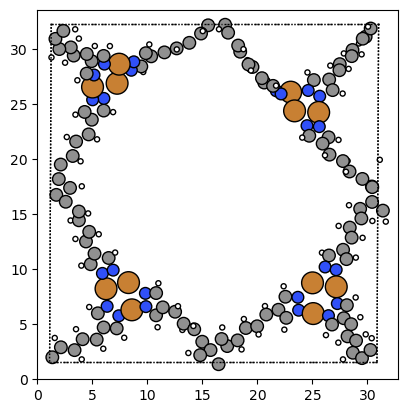

POSCAR_qmofb52c6c5_amorphous
n_atoms: 228, formula: C108H84Cu12N24


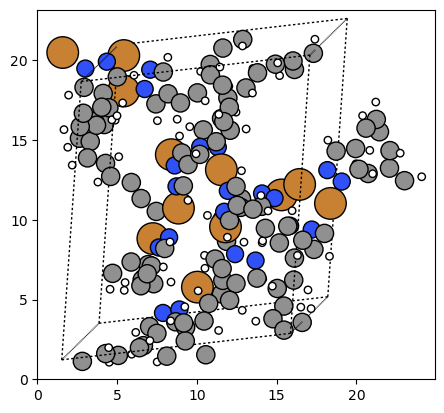

POSCAR_qmofb0f0d29_crystalline
n_atoms: 600, formula: C264H168Mg24N48O72S24


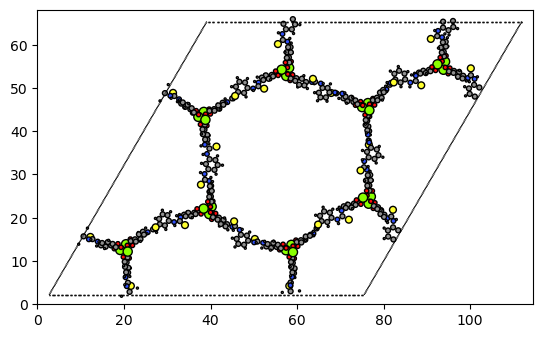

POSCAR_qmofb0f0d29_amorphous
n_atoms: 600, formula: C264H168Mg24N48O72S24


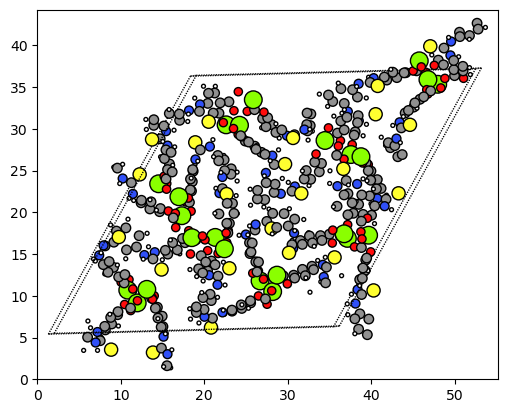

POSCAR_MOF5_crystalline
n_atoms: 424, formula: C192H96O104Zn32


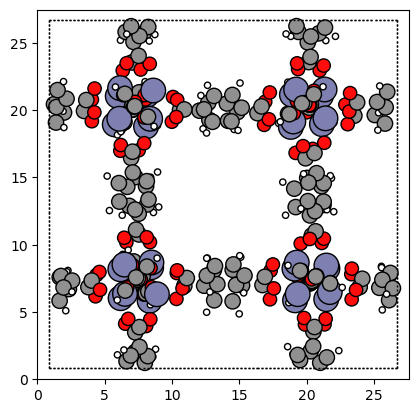

POSCAR_MOF5_amorphous
n_atoms: 424, formula: C192H96O104Zn32


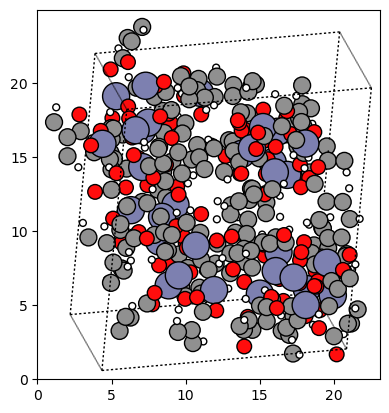

In [3]:
for struc_file in reversed(sorted(glob(str(struc_dir/'*')))):
    print(Path(struc_file).name)
    atoms = read(struc_file)
    print(f'n_atoms: {len(atoms)}, formula: {atoms.get_chemical_formula()}')
    plot_atoms(atoms, radii=0.75, rotation=("90x,90y,0z"))
    plt.show()

## trajectories

CASCADE_Example_Files_05142026/MD_Trajectories/qmofb52c6c5_NPT_1000MPa.traj: 101 frames


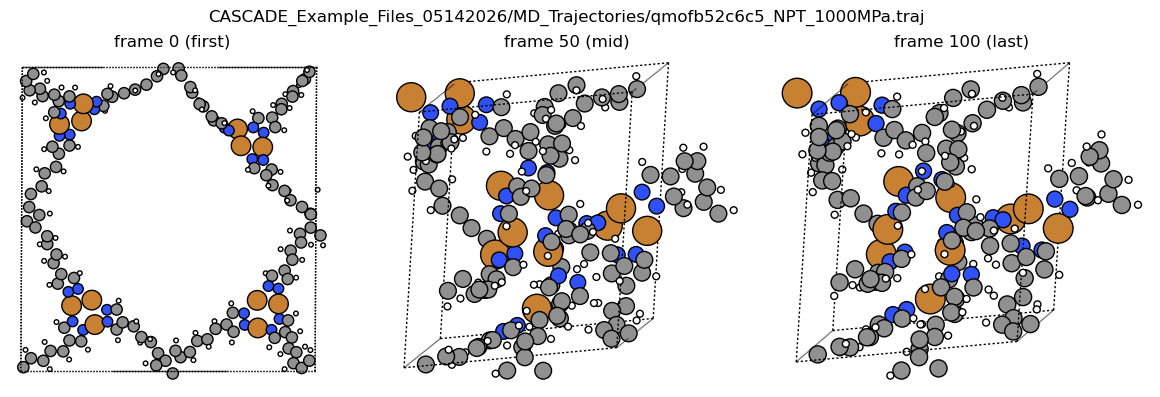

CASCADE_Example_Files_05142026/MD_Trajectories/qmofb0f0d29_NPT_1000MPa.traj: 101 frames


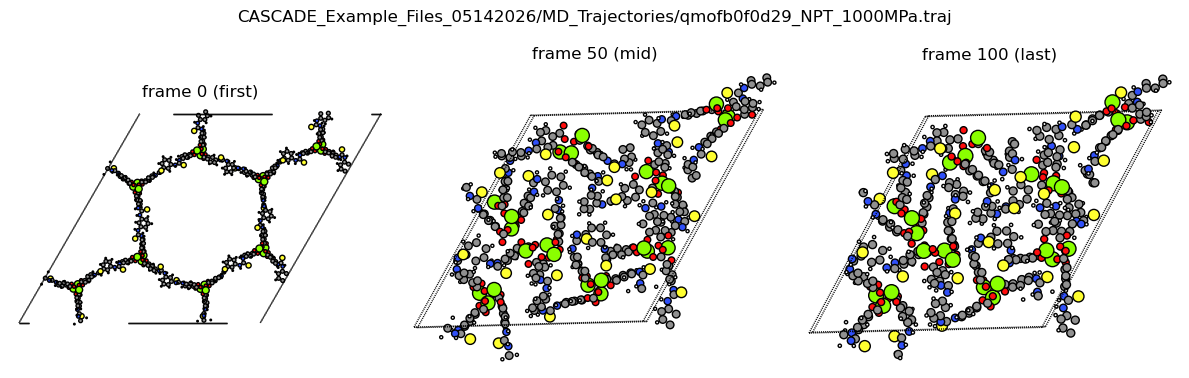

CASCADE_Example_Files_05142026/MD_Trajectories/MOF5_NPT_1000MPa.traj: 101 frames


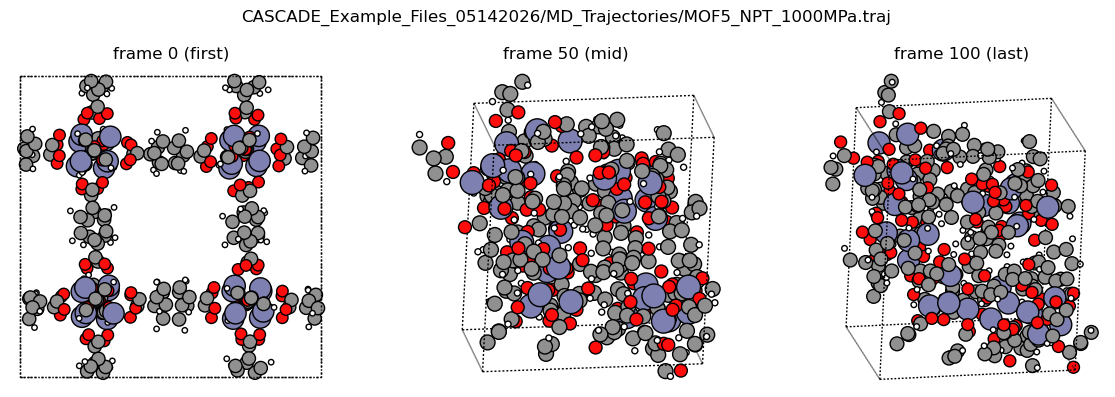

In [4]:
for traj_file in reversed(sorted(glob(str(traj_dir/'*')))):
    frames = read(traj_file, index=":")  # loads all frames as a list of Atoms
    n_frames = len(frames)
    print(f"{traj_file}: {n_frames} frames")

    idx_first, idx_mid, idx_last = 0, n_frames // 2, n_frames - 1
    indices = [idx_first, idx_mid, idx_last]
    labels = [f"frame {idx_first} (first)", f"frame {idx_mid} (mid)", f"frame {idx_last} (last)"]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, idx, label in zip(axes, indices, labels):
        plot_atoms(frames[idx], ax, radii=0.75, rotation=("90x,90y,0z"))
        ax.set_title(label)
        ax.set_axis_off()

    fig.suptitle(traj_file)
    plt.tight_layout()
    plt.show()